In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ml_df = pd.read_csv(
    '../data/cleaned/ml_dataset.csv'
)

In [3]:
ml_df.head()

,home_elo,away_elo,elo_diff,home_rank,away_rank,rank_diff,neutral,is_competitive,home_form,away_form,form_diff,home_attack_strength,away_attack_strength,home_defense_strength,away_defense_strength,elite_score_diff,adjusted_strength_diff,target
0,1767.0,2020.0,-253.0,29.0,4.0,-25.0,0,0,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0,0,1
1,2020.0,1767.0,253.0,4.0,29.0,25.0,0,0,3.000000,0.000000,3.0,4.000000,2.000000,2.000000,4.000000,0,0,2
2,1767.0,2020.0,-253.0,29.0,4.0,-25.0,0,0,2.000000,0.500000,1.5,1.000000,0.500000,0.500000,1.000000,0,0,2
3,2020.0,1767.0,253.0,4.0,29.0,25.0,0,0,2.000000,0.500000,1.5,3.000000,2.000000,2.000000,3.000000,0,0,1
4,1767.0,2020.0,-253.0,29.0,4.0,-25.0,0,0,2.333333,0.333333,2.0,1.666667,0.333333,0.333333,1.666667,0,0,2


In [4]:
X = ml_df.drop('target', axis=1)

y = ml_df['target']

In [5]:
#future unseen matches

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [8]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

In [9]:
log_preds = log_model.predict(
    X_test_scaled
)

In [10]:
log_acc = accuracy_score(
    y_test,
    log_preds
)

print("Logistic Accuracy:", log_acc)

Logistic Accuracy: 0.666443402545211


In [11]:
print(
    classification_report(
        y_test,
        log_preds
    )
)

              precision    recall  f1-score   support

           0       0.66      0.68      0.67       417
           1       0.55      0.33      0.41       389
           2       0.70      0.85      0.77       687

    accuracy                           0.67      1493
   macro avg       0.64      0.62      0.62      1493
weighted avg       0.65      0.67      0.65      1493



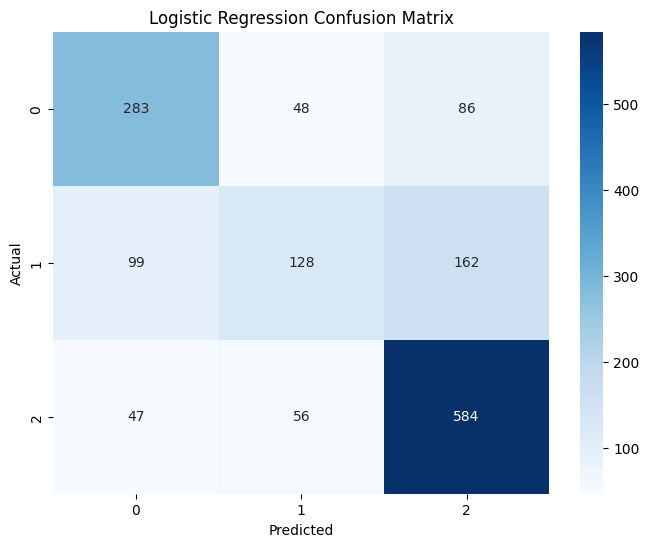

In [12]:
cm = confusion_matrix(
    y_test,
    log_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [14]:
rf_preds = rf_model.predict(X_test)

In [15]:
rf_acc = accuracy_score(
    y_test,
    rf_preds
)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.6530475552578701


In [16]:
print(
    classification_report(
        y_test,
        rf_preds
    )
)

              precision    recall  f1-score   support

           0       0.65      0.70      0.67       417
           1       0.50      0.31      0.39       389
           2       0.70      0.82      0.76       687

    accuracy                           0.65      1493
   macro avg       0.62      0.61      0.60      1493
weighted avg       0.63      0.65      0.64      1493



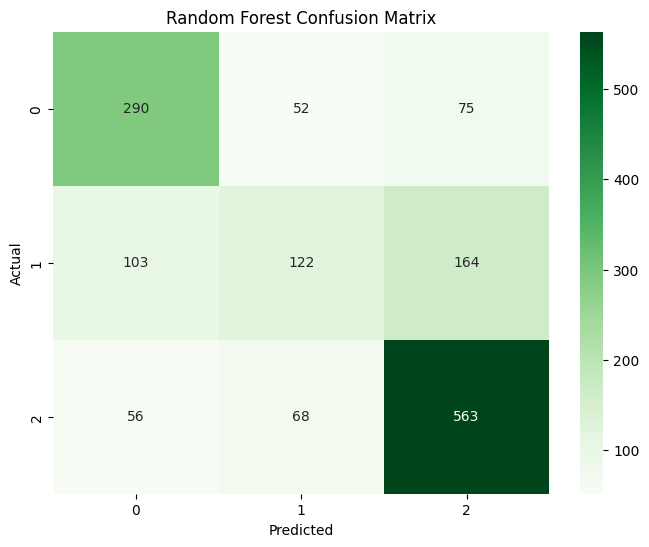

In [17]:
cm = confusion_matrix(
    y_test,
    rf_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=3, ...)

In [19]:
xgb_preds = xgb_model.predict(X_test)

In [20]:
xgb_acc = accuracy_score(
    y_test,
    xgb_preds
)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.6657736101808439


In [21]:
print(
    classification_report(
        y_test,
        xgb_preds
    )
)

              precision    recall  f1-score   support

           0       0.67      0.68      0.67       417
           1       0.55      0.41      0.47       389
           2       0.71      0.80      0.75       687

    accuracy                           0.67      1493
   macro avg       0.64      0.63      0.63      1493
weighted avg       0.66      0.67      0.66      1493



In [22]:
models = ['Logistic', 'Random Forest', 'XGBoost']

scores = [
    log_acc,
    rf_acc,
    xgb_acc
]

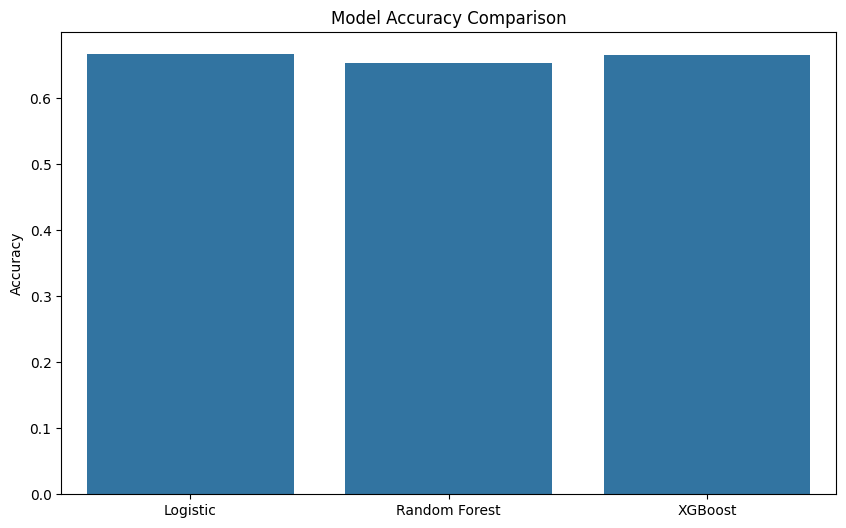

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=models,
    y=scores
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [24]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

In [25]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

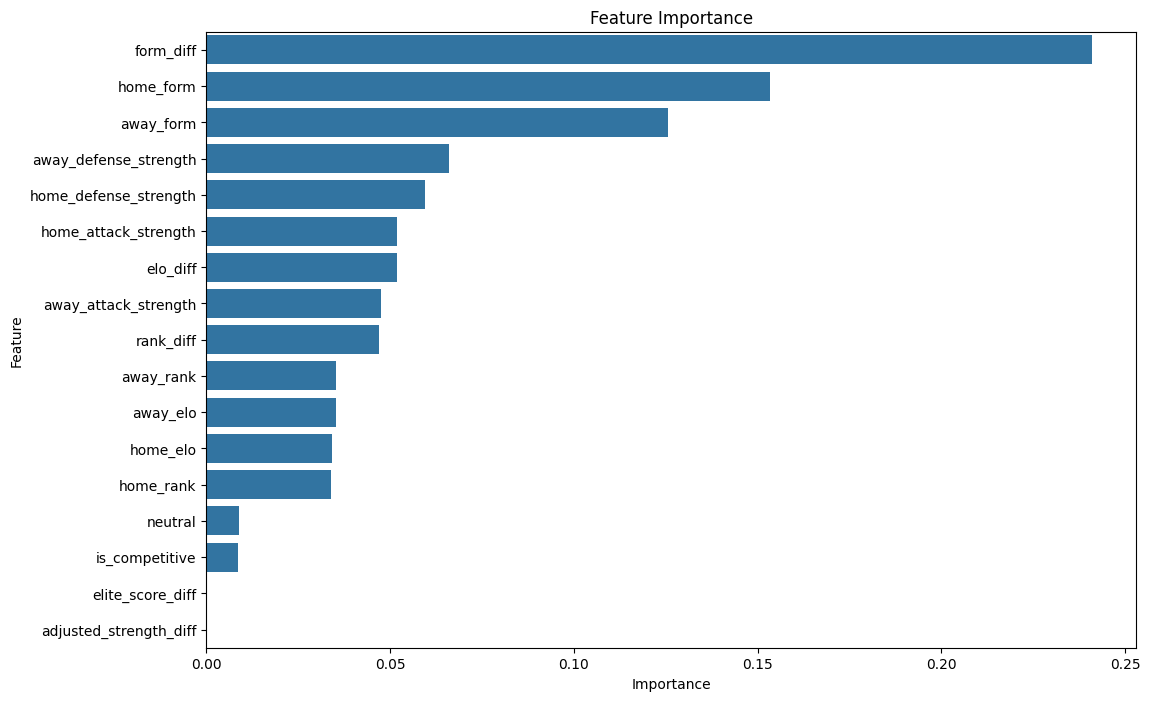

In [26]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [27]:
probs = xgb_model.predict_proba(X_test)

In [28]:
print(probs[:5])

[[8.5436570e-04 1.4247005e-01 8.5667557e-01]
 [1.3004288e-01 7.3423094e-01 1.3572623e-01]
 [6.7487347e-01 3.2377499e-01 1.3515052e-03]
 [5.8953863e-01 9.6465424e-02 3.1399590e-01]
 [2.2672851e-01 5.2695715e-01 2.4631430e-01]]


In [29]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import joblib

In [31]:
joblib.dump(
    xgb_model,
    '../models/xgb_wc_predictor.pkl'
)

['../models/xgb_wc_predictor.pkl']

In [32]:
joblib.dump(
    scaler,
    '../models/scaler.pkl'
)

['../models/scaler.pkl']